# Никитин Дмитрий
## 4217
## Вариант 2 - Классификация цветов "Flowers Dataset"

Сначала были импортированы библиотеки.

In [28]:
import os
import random
import zipfile
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import (Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization)
from sklearn.metrics import classification_report, confusion_matrix


Далее была написана функция, которая будет распаковывать архив, если он ещё не распакован.

In [29]:
def unzip_file(zip_path, extract_to="."):
    """
    Распаковывает ZIP-архив в указанную директорию.

    :param zip_path: Путь к ZIP-архиву.
    :param extract_to: Директория, куда распаковать файлы (по умолчанию текущая директория).
    """
    # Проверка, существует ли ZIP-архив
    if not os.path.exists(zip_path):
        print(f"Файл {zip_path} не найден.")
        return

    # Открытие ZIP-архива
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        # Распаковка всех файлов в указанную директорию
        zip_ref.extractall(extract_to)
        print(f"Архив {zip_path} успешно распакован в {extract_to}.")
extract_to = "flowers"    # Директория, куда распаковать файлы
if os.path.isdir(extract_to) == False or len(os.listdir(extract_to)) == 0:
  zip_path = "dataset.zip"  # Путь к ZIP-архиву
  unzip_file(zip_path, extract_to)
else:
  print("Датасет не требует распаковки")

Датасет не требует распаковки


Далее была разработана и обучена сверточная нейронная сеть для классификации изображений пяти видов цветов: ромашки, одуванчика, розы, подсолнечника и тюльпана. Изображения были подготовлены с помощью аугментации данных (вращение, масштабирование, отражение) и нормализации пикселей в диапазон [0, 1], а также разделены на обучающую и валидационную выборки. Архитектура модели включает три сверточных блока с последующей нормализацией и подвыборкой, за которыми следуют полносвязные слои с регуляризацией методом Dropout для предотвращения переобучения. Модель была скомпилирована с оптимизатором Adam и функцией потерь categorical crossentropy и обучалась в течение 50 эпох с мониторингом точности на валидационной выборке.

In [30]:
# Создание и обучение нейросети
# Параметры
img_height, img_width = 64, 64
batch_size = 32
num_classes = 5  # daisy, dandelion, rose, sunflower, tulip
epochs = 50

# Пути к данным
train_dir = "flowers/train"

# Аугментация и нормализация данных с разбиением на тренировку и валидацию
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2  # 20% на валидацию
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

# Архитектура модели
inputs = Input(shape=(img_height, img_width, 3))

# 1. Первый сверточный блок
x = Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
x = BatchNormalization()(x)
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = MaxPooling2D((2, 2))(x)

# 2. Второй сверточный блок
x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = MaxPooling2D((2, 2))(x)

# 3. Третий сверточный блок
x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
x = MaxPooling2D((2, 2))(x)

# 4. Полносвязные слои
x = Flatten()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)

# Выходной слой
outputs = Dense(num_classes, activation='softmax')(x)

# Создание модели
model = Model(inputs, outputs)

# Компиляция модели
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Обучение модели
history = model.fit(
    train_generator,
    epochs=epochs,
    validation_data=val_generator
)

Found 2198 images belonging to 5 classes.
Found 548 images belonging to 5 classes.
Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


69/69 ━━━━━━━━━━━━━━━━━━━━ 19s 177ms/step - accuracy: 0.2727 - loss: 3.5211 - val_accuracy: 0.2427 - val_loss: 1.5977
Epoch 2/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 9s 124ms/step - accuracy: 0.3285 - loss: 1.5415 - val_accuracy: 0.2883 - val_loss: 1.5894
Epoch 3/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 8s 123ms/step - accuracy: 0.3060 - loss: 1.5381 - val_accuracy: 0.2354 - val_loss: 1.5641
Epoch 4/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 7s 108ms/step - accuracy: 0.3447 - loss: 1.4826 - val_accuracy: 0.2391 - val_loss: 1.6028
Epoch 5/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 8s 119ms/step - accuracy: 0.3702 - loss: 1.4714 - val_accuracy: 0.3084 - val_loss: 1.5425
Epoch 6/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 8s 119ms/step - accuracy: 0.3971 - loss: 1.4118 - val_accuracy: 0.3412 - val_loss: 1.4509
Epoch 7/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 8s 110ms/step - accuracy: 0.4026 - loss: 1.4608 - val_accuracy: 0.2701 - val_loss: 1.6210
Epoch 8/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 10s 147ms/step - accuracy: 0.4101 - loss: 1.4015 - val_accuracy: 0.4252 - va

После обучения модели была проведена ее оценка на валидационной выборке. Сначала вычислились значения потерь и точности на валидационных данных с использованием метода evaluate, после чего была выведена точность классификации. Далее были рассчитаны предсказания модели для валидационной выборки, и с помощью функции classification_report был сформирован отчет о метриках классификации, включая точность, полноту и F-меру для каждого класса. Для дальнейшего анализа качества классификации была выведена матрица ошибок с помощью функции confusion_matrix, что позволило визуализировать, как модель справляется с различными классами и где возникают ошибки.

In [31]:
# Оценка модели на валидационной выборке
val_loss, val_acc = model.evaluate(val_generator)
print(f"\nТочность на валидационных данных: {val_acc:.4f}")

# Метрики на валидационной выборке
Y_pred = model.predict(val_generator)
y_pred = np.argmax(Y_pred, axis=1)
y_true = val_generator.classes

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=list(val_generator.class_indices.keys())))

print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred))

18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 103ms/step - accuracy: 0.6543 - loss: 0.9121

Точность на валидационных данных: 0.6843
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms/step

Classification Report:
              precision    recall  f1-score   support

       daisy       0.22      0.21      0.21       100
   dandelion       0.22      0.20      0.21       129
        rose       0.16      0.14      0.15        99
   sunflower       0.20      0.22      0.21        99
       tulip       0.19      0.22      0.21       121

    accuracy                           0.20       548
   macro avg       0.20      0.20      0.20       548
weighted avg       0.20      0.20      0.20       548


Confusion Matrix:
[[21 24 20 14 21]
 [22 26 20 21 40]
 [15 22 14 25 23]
 [14 24 11 22 28]
 [25 23 20 26 27]]


По результатам оценки обученной модели на валидационной выборке была достигнута общая точность 68,43%, однако подробный анализ метрик классификации показал, что модель испытывает трудности в распознавании конкретных классов. Согласно отчету о классификации, показатели precision, recall и F1-меры для всех классов находятся на уровне около 20%, что свидетельствует о слабой способности модели точно идентифицировать изображения отдельных видов цветов. Макро- и взвешенные средние значения метрик также подтверждают низкую эффективность классификации. Матрица ошибок показывает значительное количество ошибок между всеми классами, что говорит о том, что модель путает цветы между собой практически равномерно. В целом, результаты интерпретируются как свидетельство того, что модель недостаточно хорошо научилась различать категории. Вероятно, проявляется небольшой размер обучающей выборки.

Далее были выведены графики изменения Accuracy и Loss в процессе обучения модели.

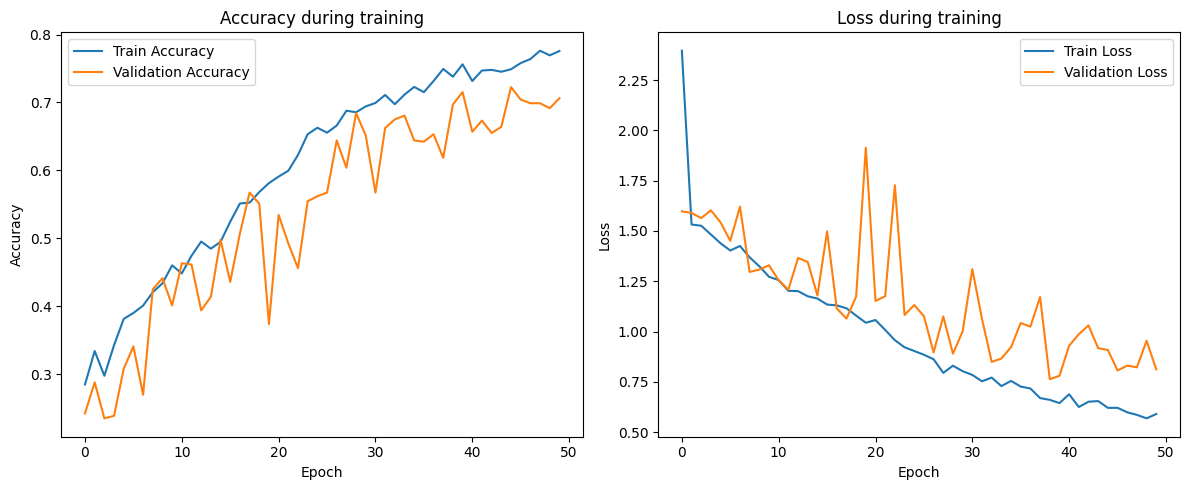

In [32]:
# Визуализация Accuracy и Loss
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy during training')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss during training')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.savefig("accuracy and loss.png")
plt.show()

Графики показывают, что модель эффективно обучается, так как accuracy растёт, а loss падает.

Далее были выведены 8 случайных предсказаний модели с примерами.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


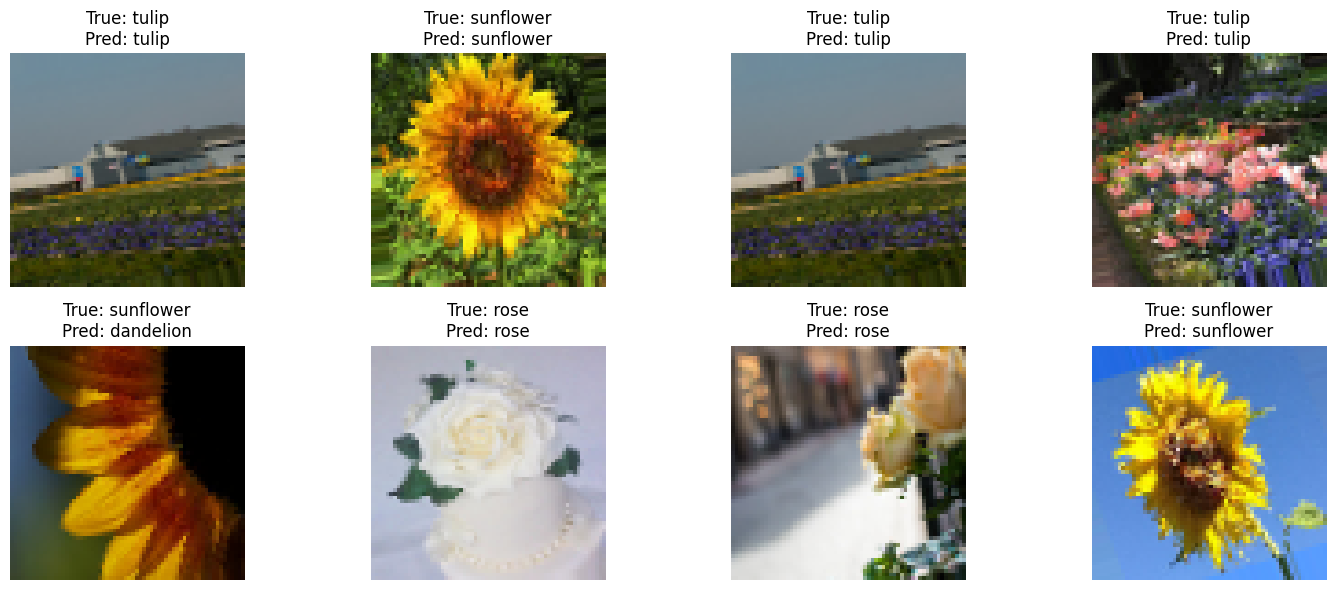

In [34]:
# Примеры предсказаний на валидационных данных
sample_images, sample_labels = next(val_generator)
sample_preds = model.predict(sample_images)
sample_preds_labels = np.argmax(sample_preds, axis=1)

plt.figure(figsize=(15, 6))
for i in range(8):
    idx = random.randint(0, batch_size - 1)
    plt.subplot(2, 4, i + 1)
    plt.imshow(sample_images[idx])
    true_label = list(val_generator.class_indices.keys())[np.argmax(sample_labels[idx])]
    pred_label = list(val_generator.class_indices.keys())[sample_preds_labels[idx]]
    plt.title(f"True: {true_label}\nPred: {pred_label}")
    plt.axis('off')
plt.tight_layout()
plt.savefig("samples.png")
plt.show()

В ходе работы была разработана и обучена сверточная нейронная сеть для классификации изображений пяти видов цветов, а также проведена ее оценка на валидационной выборке. Модель достигла общей точности 68,43%, что является неплохим результатом для первой версии, однако более детальный анализ показал, что точность, полнота и F1-мера по каждому отдельному классу находятся на уровне около 20%. Это свидетельствует о том, что модель испытывает трудности в различении отдельных категорий и, вероятно, склонна делать предсказания в пользу некоторых классов чаще других. Матрица ошибок подтверждает, что ошибки равномерно распределены между всеми классами, что указывает на недостаточную способность модели выделять характерные признаки цветов. В целом, полученные результаты показывают, что выбранная архитектура имеет потенциал, но требует дальнейших улучшений, таких как увеличение объема обучающей выборки, усиление аугментации, настройка гиперпараметров или усложнение модели для более глубокого захвата особенностей данных.